In [1]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = wifi-secure4-735.sri.ucl.ac.be
threads = 1
workers = 1
BLAS threads = 4


In [2]:
using Eliashberg
using CairoMakie


[ Info: Precompiling Eliashberg [adbadfb0-2f75-4cd8-9a77-6e8457d2b59b] (cache misses: include_dependency fsize change (2), mismatched flags (18))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1D Tight-Binding model 

In [3]:
tb_graphene = build_model_from_wannier90("graphene_tb.dat", -2.3042, [true, true, false])
cell = tb_graphene.cell
kgrid = generate_reciprocal_lattice(cell, 50, 50)
path = generate_kpath(cell; n_pts_per_segment=200)

LoadError: ArgumentError: Expected 3 sampling dimensions for a 3-dimensional primitive-vector matrix, got 2.

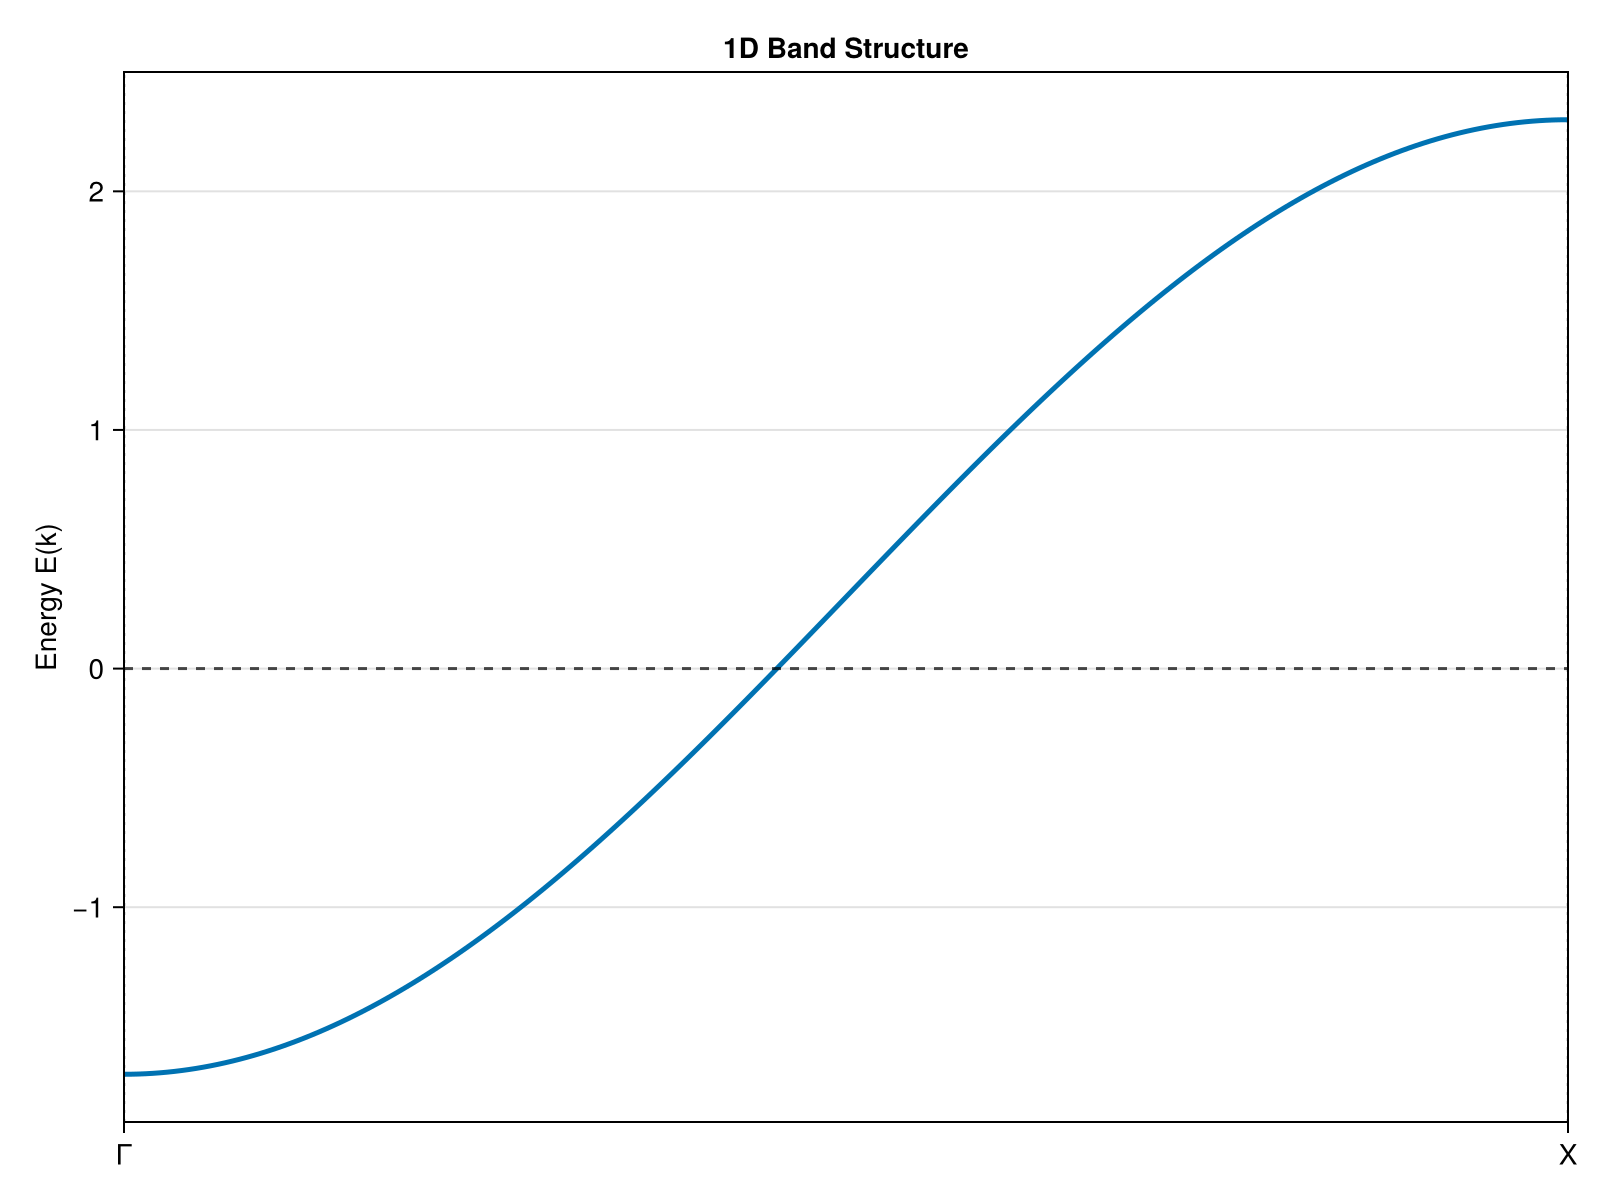

In [ ]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_1d_eband.png", f)
f


### Competition with CDW

### Competition with CDW

### Coulomb interaction

In [ ]:
interaction = BareCoulombInteraction(0.01)

fluctuation = DirectChannel()
phis = range(0.0, 1.0, length=100)
Ts = range(0.1, 0.4, length=10)

omegas = range(0.0, 5.0, length=400)
T_plasmon = 0.01

0.01

In [ ]:
# 对当前版本的包，等离激元示例直接展示裸密度响应的动态谱函数。
# 相互作用修正可以在后处理阶段进一步叠加到 χ₀(q, ω) 上。

spectral_matrix = scan_spectral_function(tb, interaction, fluctuation, kgrid, path, omegas; T=T_plasmon, η=0.02)

[ Info: Scanning spectral function over 201 parameter samples and 400 frequency samples...


201×400 Matrix{Float64}:
  0.0          0.0          …  0.0         0.0         0.0
 -6.09493e-23  3.89029e-8      4.51177e-8  4.48028e-8  4.44907e-8
  1.97951e-22  1.56261e-7      1.80501e-7  1.79241e-7  1.77992e-7
 -3.95944e-22  3.54043e-7      4.06239e-7  4.03402e-7  4.00592e-7
 -2.61162e-22  6.35593e-7      7.22483e-7  7.17436e-7  7.12435e-7
  5.04135e-22  1.00574e-6   …  1.12944e-6  1.12155e-6  1.11373e-6
 -2.42295e-21  1.47096e-6      1.62739e-6  1.61601e-6  1.60473e-6
 -4.32028e-21  2.03954e-6      2.21664e-6  2.20113e-6  2.18577e-6
  7.42368e-22  2.72194e-6      2.89761e-6  2.87732e-6  2.85721e-6
  7.7549e-21   3.53106e-6      3.67073e-6  3.645e-6    3.61951e-6
  1.22274e-21  4.48279e-6   …  4.53651e-6  4.50469e-6  4.47315e-6
 -6.24385e-21  5.59656e-6      5.49553e-6  5.45693e-6  5.41869e-6
 -2.19759e-20  6.89616e-6      6.54841e-6  6.50237e-6  6.45675e-6
  ⋮                         ⋱                          
 -8.07117e-7   0.000452907     0.0030483   0.00299034  0.0029341
 -7

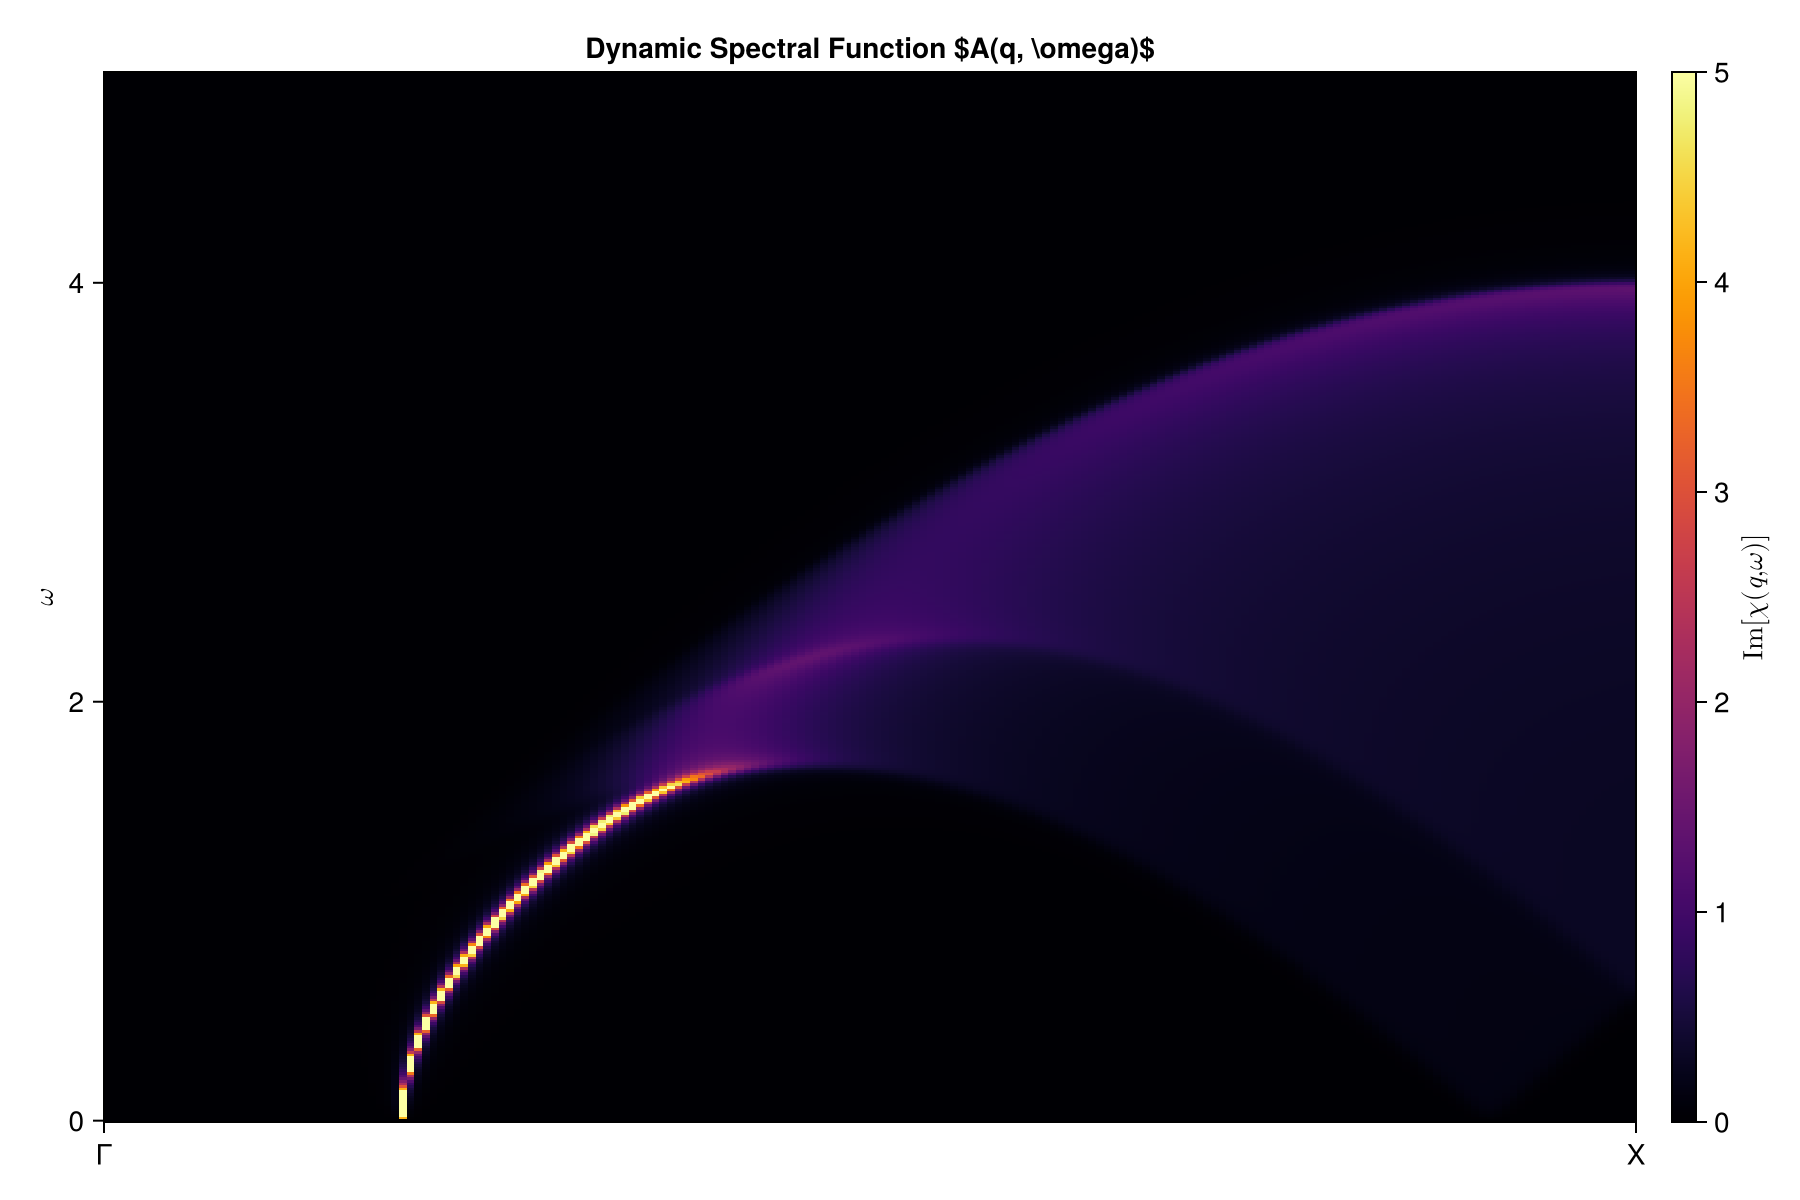

CairoMakie.Screen{IMAGE}


In [ ]:
fig_plasmon = plot_spectral_function(path, omegas, spectral_matrix, colorrange=(0.0, 5.0))
display(fig_plasmon)

In [ ]:
band_data = compute_renormalized_band_data(Ts, fluctuation, tb, interaction, kgrid, path)

RenormalizedBandData{1}(KPath{1}(StaticArraysCore.SVector{1, Float64}[[0.0], [0.010471975511965976], [0.020943951023931952], [0.03141592653589793], [0.041887902047863905], [0.05235987755982988], [0.06283185307179585], [0.07330382858376185], [0.08377580409572781], [0.09424777960769379]  …  [2.0001473227855016], [2.0106192982974673], [2.0210912738094335], [2.0315632493213993], [2.0420352248333655], [2.0525072003453313], [2.0629791758572975], [2.0734511513692633], [2.0839231268812295], [2.0943951023931953]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201], ["Γ", "X"]), [-1.7, -1.6997532649633211, -1.6990131207314632, -1.69777974992394, -1.696053456856543, -1.6938346674662559, -1.69112392920616, -1.6879219109103594, -1.6842294026289557, -1.680047315433115  …  2.280047315433115, 2.2842294026289554, 2.287921910910359, 2.29112392920616, 2.293834667466256, 2.296053456856543, 2.29777974992394, 2.299013120731463, 2.299753264963321

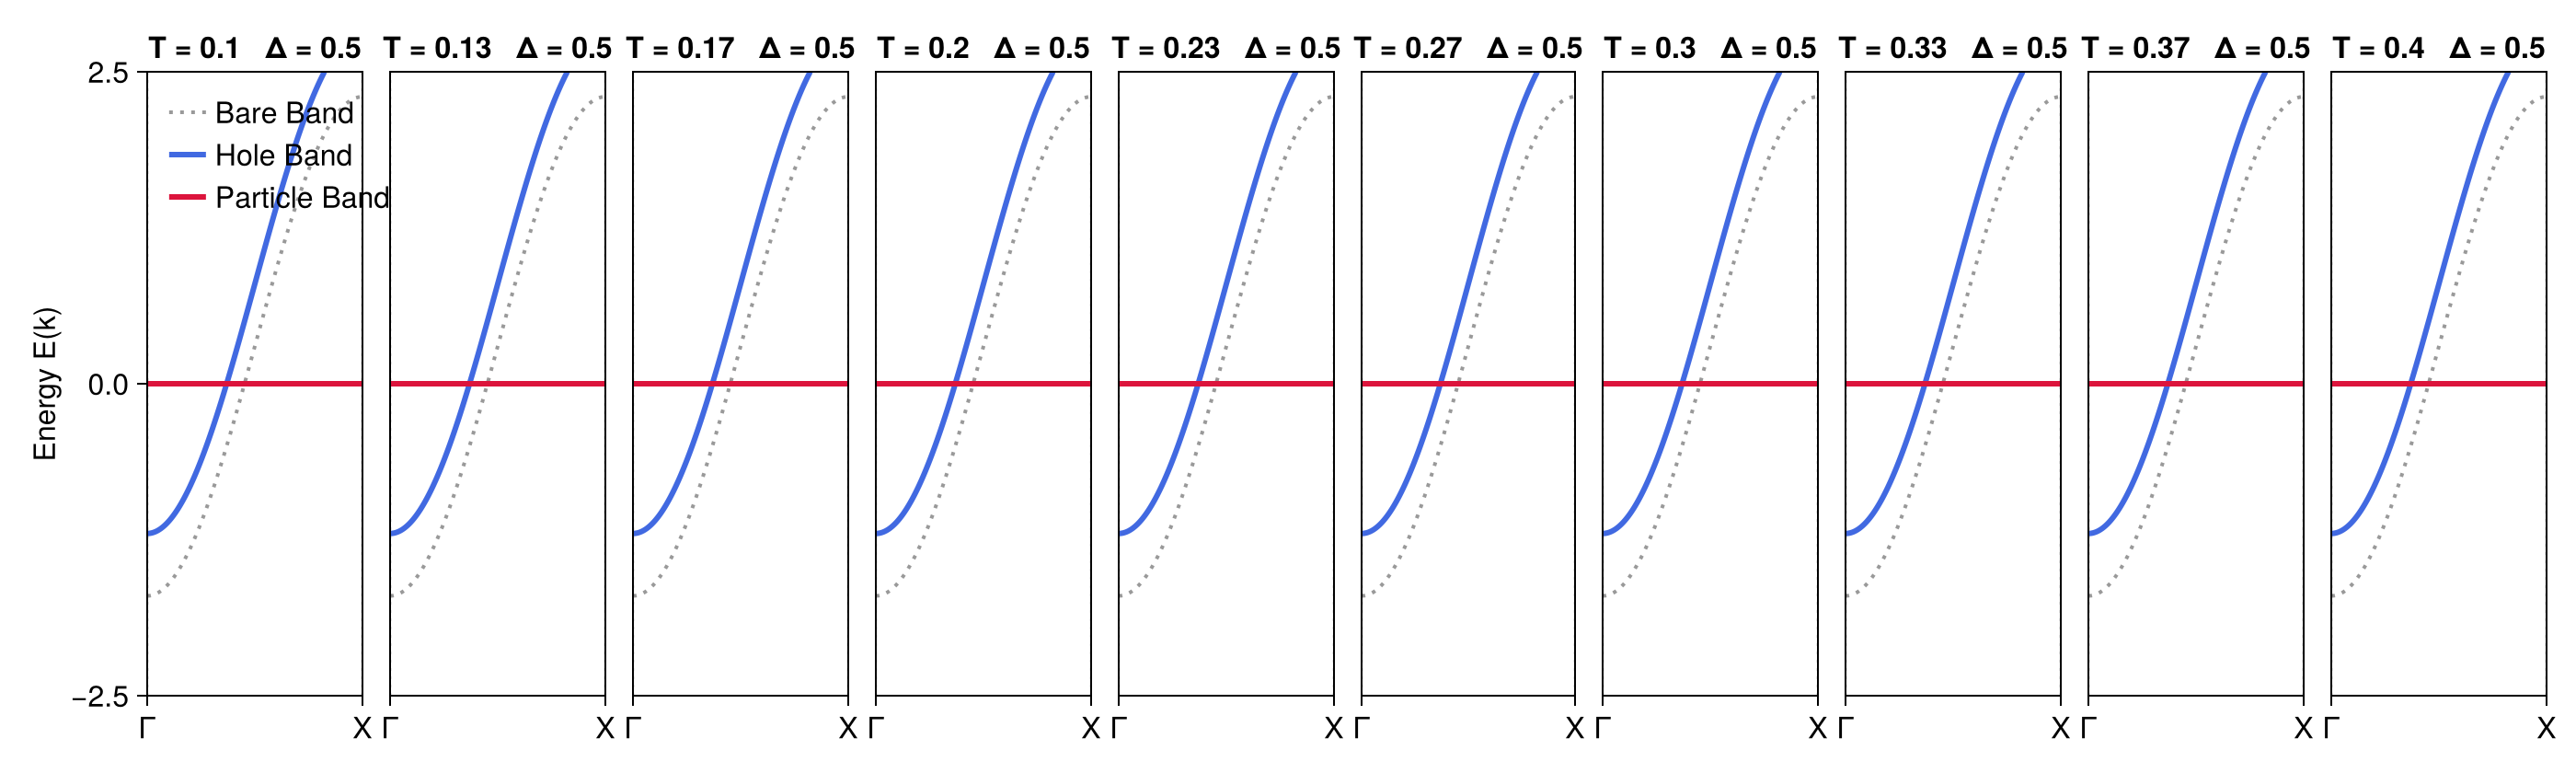

In [ ]:
plot(band_data)

## 2D Tight-Binding model 

In [3]:
lattice= SquareLattice(1.5) # 晶格常数 1.5 的二维正方晶格
kgrid = generate_reciprocal_lattice(lattice, 50, 50)

tb = TightBinding(lattice, 1.0, -0.3)

path = generate_kpath(lattice, n_pts_per_segment=200)

KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.010471975511965976, 0.0], [0.020943951023931952, 0.0], [0.03141592653589793, 0.0], [0.041887902047863905, 0.0], [0.05235987755982988, 0.0], [0.06283185307179585, 0.0], [0.07330382858376185, 0.0], [0.08377580409572781, 0.0], [0.09424777960769379, 0.0]  …  [0.0942477796076937, 0.0942477796076937], [0.08377580409572793, 0.08377580409572793], [0.07330382858376172, 0.07330382858376172], [0.06283185307179595, 0.06283185307179595], [0.05235987755982974, 0.05235987755982974], [0.04188790204786397, 0.04188790204786397], [0.031415926535897754, 0.031415926535897754], [0.020943951023931984, 0.020943951023931984], [0.01047197551196577, 0.01047197551196577], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201, 401, 601], ["Γ", "X", "M", "Γ"])

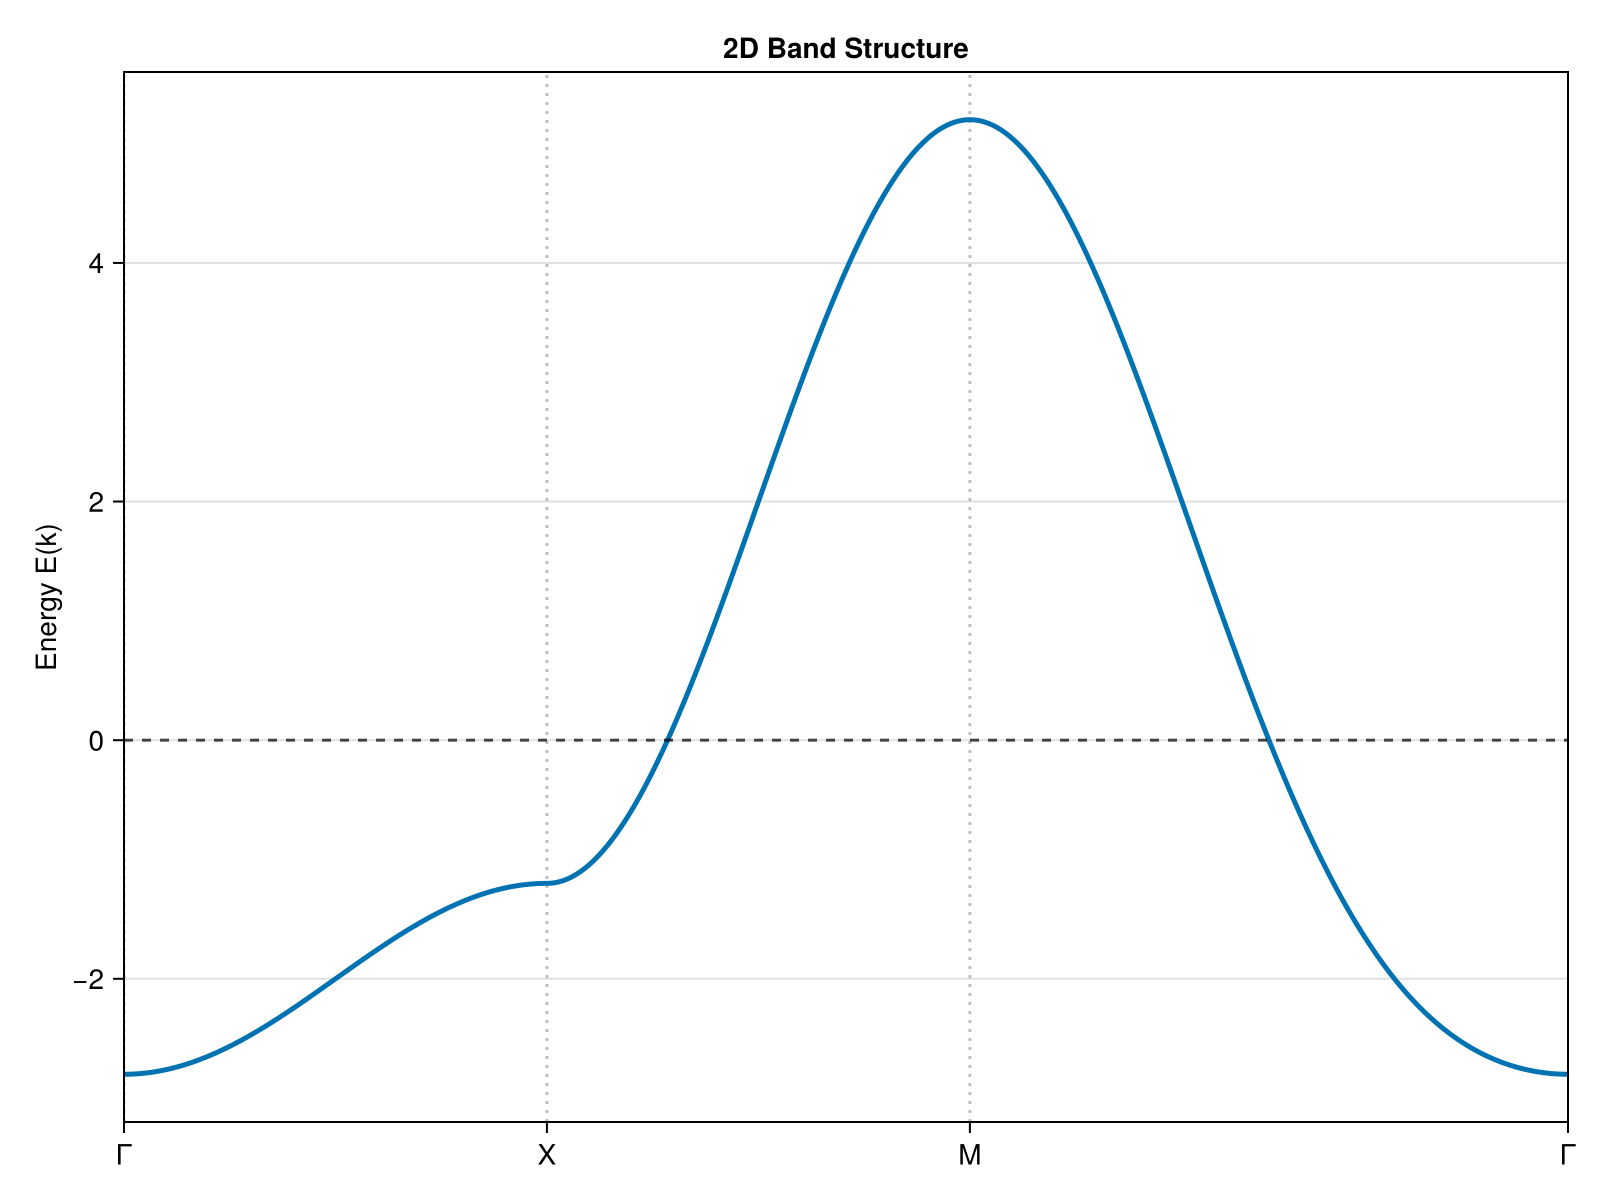

In [4]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_1d_eband.png", f)
f


### Coulomb interaction

In [9]:
interaction = BareCoulombInteraction(0.01)

fluctuation = DirectChannel()
phis = range(0.0, 1.0, length=100)
Ts = range(0.1, 0.4, length=6)

omegas = range(0.0, 5.0, length=400)
T_plasmon = 0.01

0.01

In [10]:
band_data = compute_renormalized_band_data(Ts, fluctuation, tb, interaction, kgrid, path)

RenormalizedBandData{2}(KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.010471975511965976, 0.0], [0.020943951023931952, 0.0], [0.03141592653589793, 0.0], [0.041887902047863905, 0.0], [0.05235987755982988, 0.0], [0.06283185307179585, 0.0], [0.07330382858376185, 0.0], [0.08377580409572781, 0.0], [0.09424777960769379, 0.0]  …  [0.0942477796076937, 0.0942477796076937], [0.08377580409572793, 0.08377580409572793], [0.07330382858376172, 0.07330382858376172], [0.06283185307179595, 0.06283185307179595], [0.05235987755982974, 0.05235987755982974], [0.04188790204786397, 0.04188790204786397], [0.031415926535897754, 0.031415926535897754], [0.020943951023931984, 0.020943951023931984], [0.01047197551196577, 0.01047197551196577], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201, 401, 601], ["Γ", "X", "M", "Γ"]), [-2.8; -2.7999013059853284; … ; -2.7998025937072035; -2.8;;], [-2.3; -2.2999013059853284; … ; -2.2998

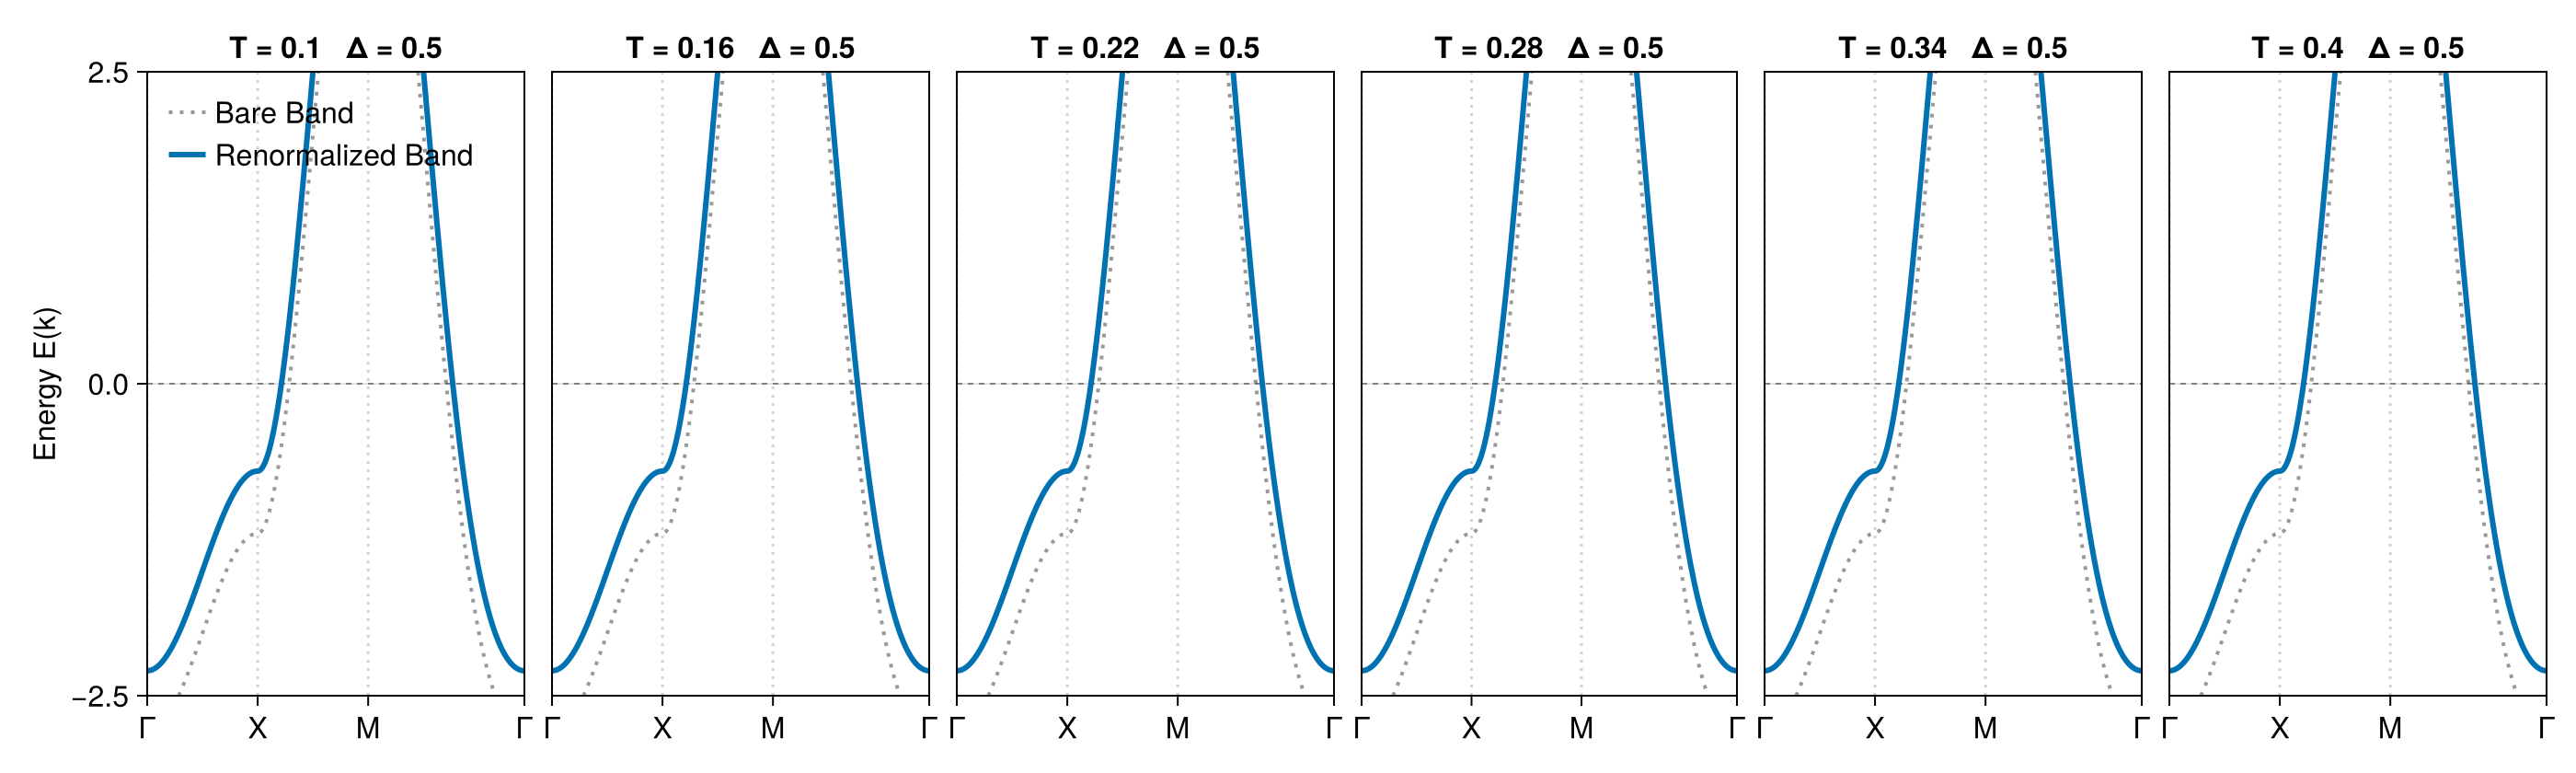

In [11]:
plot(band_data)

In [ ]:
# 对当前版本的包，等离激元示例直接展示裸密度响应的动态谱函数。
# 相互作用修正可以在后处理阶段进一步叠加到 χ₀(q, ω) 上。

spectral_matrix = scan_spectral_function(tb, interaction, fluctuation, kgrid, path, omegas; T=T_plasmon, η=0.02)

[ Info: Scanning spectral function over 601 parameter samples and 400 frequency samples...


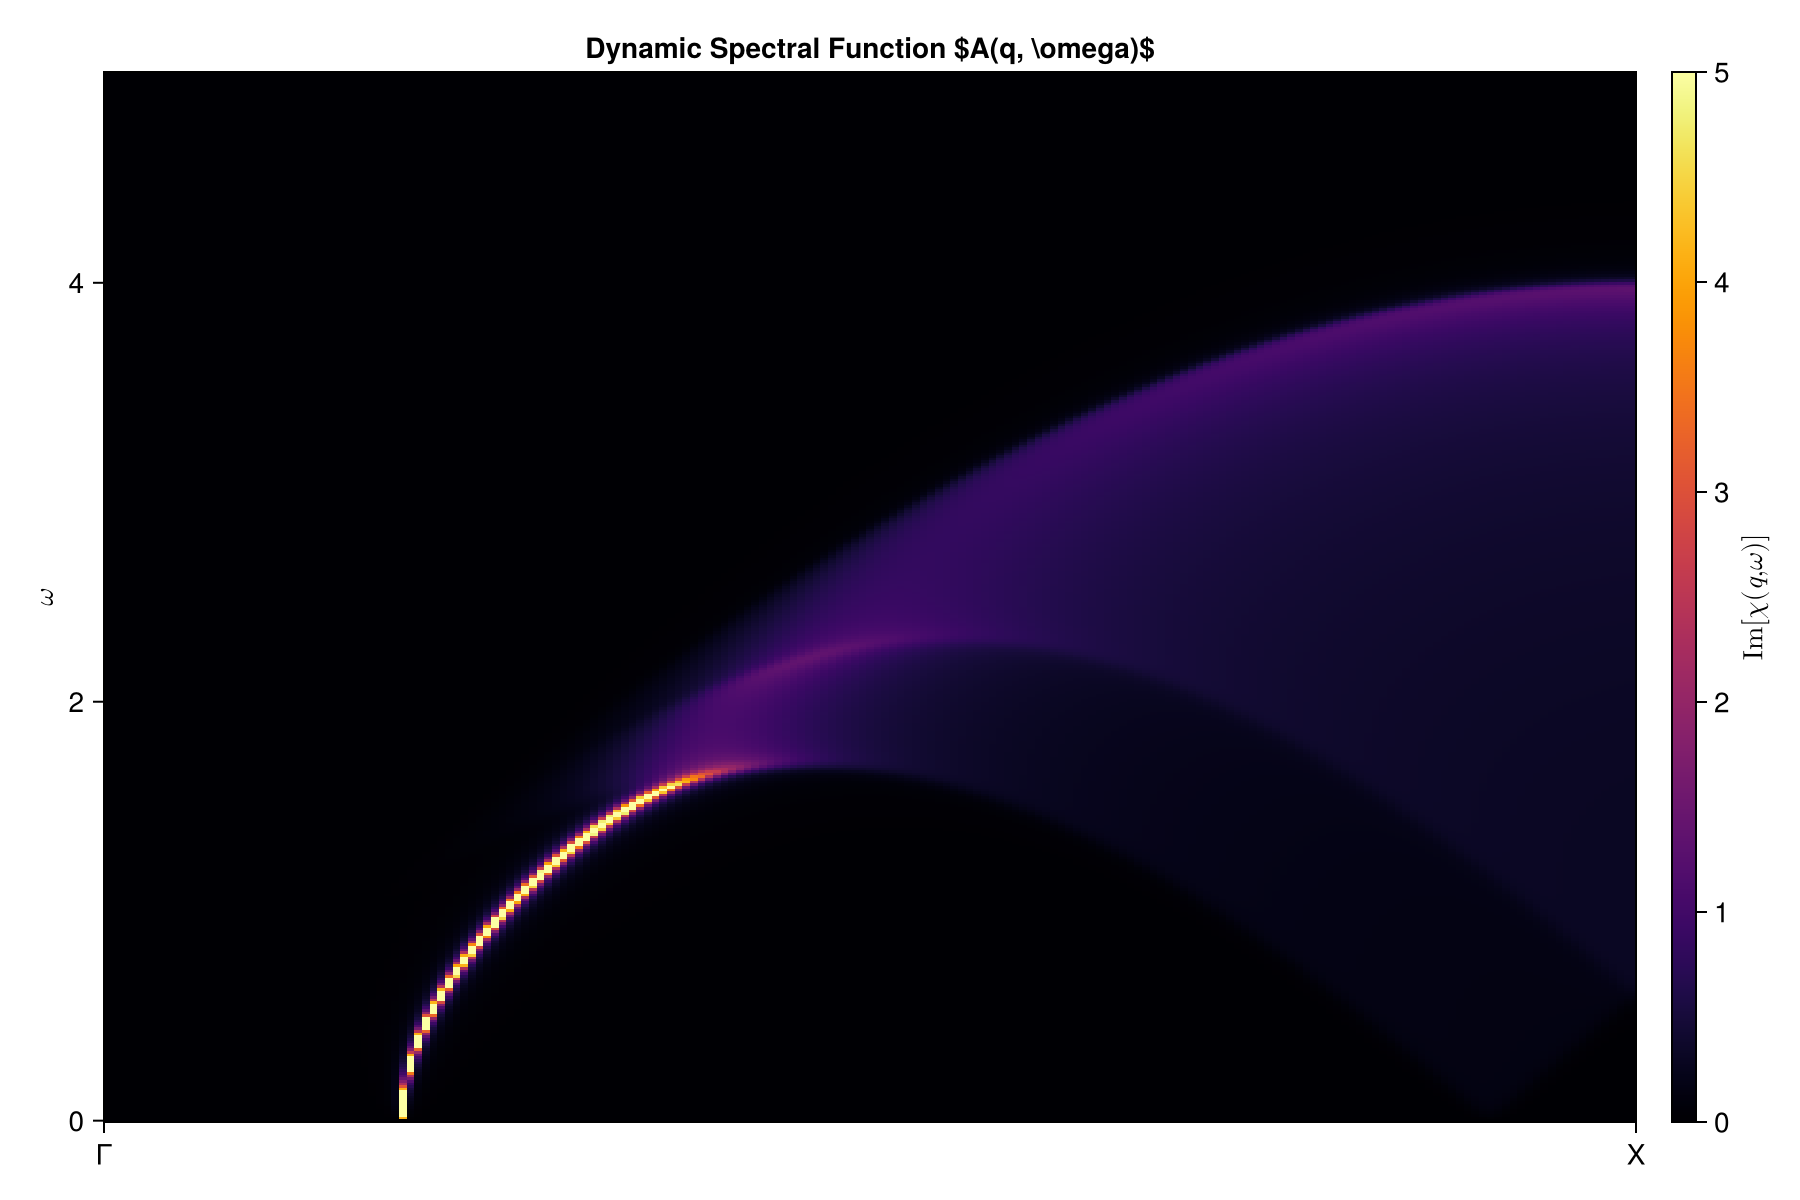

CairoMakie.Screen{IMAGE}


In [ ]:
fig_plasmon = plot_spectral_function(path, omegas, spectral_matrix, colorrange=(0.0, 5.0))
display(fig_plasmon)